# 05 - Reaction Enthalpies & Heats of Combustion

Because `pyglenn`'s $H^\circ(T)$ is *standardized* (it includes each species'
enthalpy of formation, notebook 04), the standard reaction enthalpy is just a
stoichiometric sum of enthalpies:

$$\Delta H_\mathrm{rxn}(T) = \sum_{\text{products}} \nu_j\,H^\circ_j(T)
   - \sum_{\text{reactants}} \nu_i\,H^\circ_i(T).$$

No separate table of formation enthalpies, no Hess-law bookkeeping — one call
per species. We use this to compute heats of combustion (LHV/HHV), their
temperature dependence (Kirchhoff's law) and to demonstrate Hess's law.

In [1]:
from pyglenn import ThermochemicalCalculator, R

_INDEX = {}

def species_id(calc, name):
    """Return the database id of the species whose *name* matches exactly.

    ``get_available_species`` matches substrings of both the name and the
    formula and caps its result at 20 rows, so short names such as ``"O2"`` can
    be crowded out by entries like ``"AL2O2"`` or ``"CO2"``. To be robust we
    build a full name -> id index once (cached across the session) and look up
    the exact name in it.
    """
    if not _INDEX:
        _INDEX.update({s["name"]: s["id"] for s in calc.get_available_species("")})
    if name not in _INDEX:
        raise ValueError(f"Species {name!r} not found in the database")
    return _INDEX[name]

print("Universal gas constant R =", R, "J/(mol.K)")


Universal gas constant R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


## 1. A general reaction-enthalpy function

Reactions are expressed as `{species_name: stoichiometric_coefficient}` dicts.
The helper returns $\Delta H_\mathrm{rxn}$ in J/mol at any temperature.

In [3]:
def reaction_enthalpy(calc, reactants, products, T=298.15):
    """Standard reaction enthalpy in J/mol at temperature T (Kelvin)."""
    def total(mix):
        h = 0.0
        for name, nu in mix.items():
            h += nu * calc.calculate_properties(species_id(calc, name), T)["h_relative"]
        return h
    return total(products) - total(reactants)

## 2. Validation against known reactions

Four textbook reactions at 298.15 K (gaseous water product). The computed values
match accepted standard reaction enthalpies to a fraction of a kJ/mol.

In [4]:
REACTIONS = {
    "CO + 1/2 O2 -> CO2":              ({"CO": 1, "O2": 0.5}, {"CO2": 1}, -283.0),
    "H2 + 1/2 O2 -> H2O(g)":           ({"H2": 1, "O2": 0.5}, {"H2O": 1}, -241.8),
    "CH4 + 2 O2 -> CO2 + 2 H2O(g)":    ({"CH4": 1, "O2": 2}, {"CO2": 1, "H2O": 2}, -802.3),
    "C2H5OH + 3 O2 -> 2 CO2 + 3 H2O":  ({"C2H5OH": 1, "O2": 3}, {"CO2": 2, "H2O": 3}, -1277.5),
}

rows = []
with ThermochemicalCalculator() as calc:
    for label, (reac, prod, ref) in REACTIONS.items():
        dh = reaction_enthalpy(calc, reac, prod) / 1000.0
        rows.append({"reaction": label, "pyglenn [kJ/mol]": dh,
                     "reference [kJ/mol]": ref, "err": abs(dh - ref)})
print(pd.DataFrame(rows).set_index("reaction").to_string())

                                pyglenn [kJ/mol]  reference [kJ/mol]   err
reaction                                                                  
CO + 1/2 O2 -> CO2                      -282.973            -283.000 0.027
H2 + 1/2 O2 -> H2O(g)                   -241.825            -241.800 0.025
CH4 + 2 O2 -> CO2 + 2 H2O(g)            -802.557            -802.300 0.257
C2H5OH + 3 O2 -> 2 CO2 + 3 H2O        -1,277.541          -1,277.500 0.041


## 3. Heats of combustion (Lower Heating Value)

The **lower heating value** (LHV) is the heat released per mole of fuel with the
product water left as **vapour**: $\text{LHV} = -\Delta H_\mathrm{comb}$. We
compute it for a range of fuels and also express it per kilogram, the figure of
merit for transport fuels.

In [5]:
# fuel -> (moles O2, product CO2, product H2O)  for complete combustion
FUELS = {
    "H2":               (0.5, 0, 1),
    "CH4":              (2.0, 1, 2),
    "C3H8":             (5.0, 3, 4),
    "C2H5OH":           (3.0, 2, 3),
    "C8H18,isooctane":  (12.5, 8, 9),
}

def molar_mass(calc, name):
    sid = species_id(calc, name)
    return calc.db.get_species_data(sid)["molecular_weight"]

rows = []
with ThermochemicalCalculator() as calc:
    for fuel, (nO2, nCO2, nH2O) in FUELS.items():
        dh = reaction_enthalpy(calc, {fuel: 1, "O2": nO2},
                               {"CO2": nCO2, "H2O": nH2O})
        lhv = -dh                       # J/mol
        M = molar_mass(calc, fuel)      # g/mol
        rows.append({"fuel": fuel, "M [g/mol]": M,
                     "LHV [kJ/mol]": lhv / 1000.0,
                     "LHV [MJ/kg]": lhv / M / 1000.0})

lhv_df = pd.DataFrame(rows).set_index("fuel").sort_values("LHV [MJ/kg]", ascending=False)
print(lhv_df.to_string())

                 M [g/mol]  LHV [kJ/mol]  LHV [MJ/kg]
fuel                                                 
H2                   2.016       241.825      119.960
CH4                 16.042       802.557       50.027
C3H8                44.096     2,043.142       46.334
C8H18,isooctane    114.229     5,100.475       44.652
C2H5OH              46.068     1,277.541       27.731


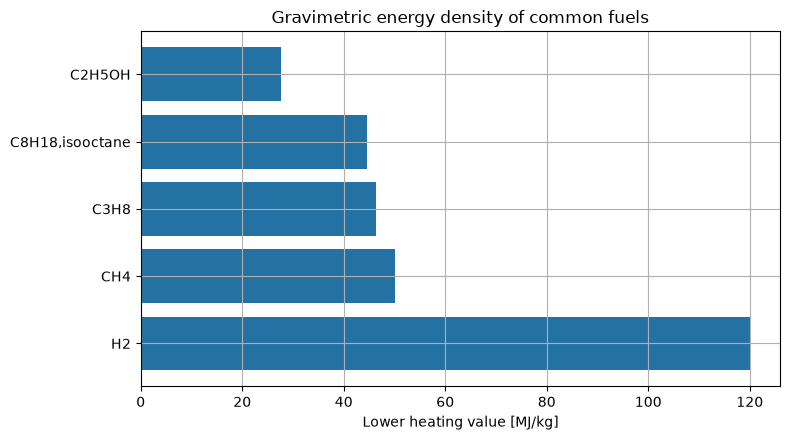

In [6]:
fig, ax = plt.subplots()
ax.barh(lhv_df.index, lhv_df["LHV [MJ/kg]"], color="#2471a3")
ax.set_xlabel("Lower heating value [MJ/kg]")
ax.set_title("Gravimetric energy density of common fuels")
fig.tight_layout()
plt.show()

## 4. Higher Heating Value (HHV)

If the product water condenses to **liquid**, its latent heat is recovered and
the released energy is larger — the **higher heating value**. The difference is
the enthalpy of vaporisation of the produced water:

$$\text{HHV} = \text{LHV} + n_{\mathrm{H_2O}}\,\Delta_\mathrm{vap} H_{\mathrm{H_2O}},
\qquad \Delta_\mathrm{vap} H \approx 44.0\ \text{kJ/mol at 298 K}.$$

We obtain $\Delta_\mathrm{vap}H$ from the database itself as
$H^\circ_{\mathrm{H_2O(g)}} - H^\circ_{\mathrm{H_2O(L)}}$ when liquid water is in
range, falling back to 44.0 kJ/mol otherwise.

In [7]:
with ThermochemicalCalculator() as calc:
    gas = calc.calculate_properties(species_id(calc, "H2O"), 298.15)["h_relative"]
    liqp = calc.calculate_properties(species_id(calc, "H2O(L)"), 298.15)
    if liqp is not None:
        dvap = (gas - liqp["h_relative"]) / 1000.0
        source = "database (H2O gas - H2O liquid)"
    else:
        dvap = 44.0
        source = "literature fallback"
print(f"Enthalpy of vaporisation of water used: {dvap:.2f} kJ/mol  [{source}]")

rows = []
with ThermochemicalCalculator() as calc:
    for fuel, (nO2, nCO2, nH2O) in FUELS.items():
        lhv = -reaction_enthalpy(calc, {fuel: 1, "O2": nO2},
                                 {"CO2": nCO2, "H2O": nH2O}) / 1000.0
        hhv = lhv + nH2O * dvap
        rows.append({"fuel": fuel, "LHV [kJ/mol]": lhv, "HHV [kJ/mol]": hhv,
                     "HHV-LHV [kJ/mol]": hhv - lhv})
print(pd.DataFrame(rows).set_index("fuel").to_string())

Enthalpy of vaporisation of water used: 44.00 kJ/mol  [database (H2O gas - H2O liquid)]
                 LHV [kJ/mol]  HHV [kJ/mol]  HHV-LHV [kJ/mol]
fuel                                                         
H2                    241.825       285.828            44.004
CH4                   802.557       890.565            88.008
C3H8                2,043.142     2,219.158           176.015
C2H5OH              1,277.541     1,409.552           132.012
C8H18,isooctane     5,100.475     5,496.509           396.035


## 5. Temperature dependence — Kirchhoff's law

Reaction enthalpy varies with temperature because products and reactants have
different heat capacities:

$$\frac{d(\Delta H_\mathrm{rxn})}{dT} = \Delta C_p
  = \sum_{\text{prod}}\nu_j C_{p,j} - \sum_{\text{reac}}\nu_i C_{p,i}.$$

We plot $\Delta H_\mathrm{rxn}(T)$ for methane and hydrogen combustion. Both are
weak functions of $T$ (small $\Delta C_p$), which is why room-temperature heats
of combustion are often used across a wide range.

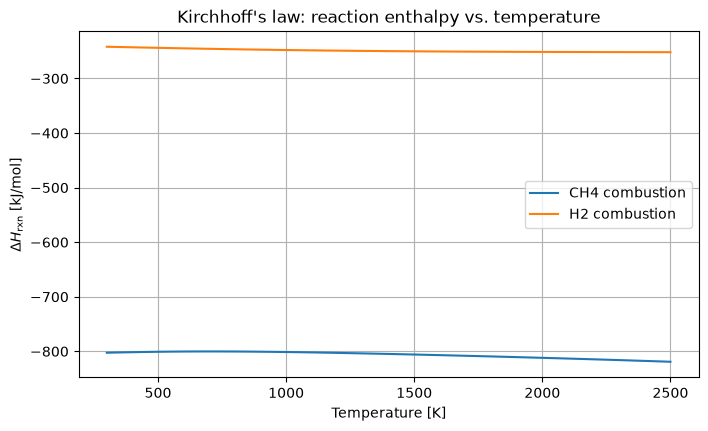

In [8]:
Tgrid = np.linspace(300, 2500, 60)
combustions = {
    "CH4 combustion": ({"CH4": 1, "O2": 2}, {"CO2": 1, "H2O": 2}),
    "H2 combustion":  ({"H2": 1, "O2": 0.5}, {"H2O": 1}),
}
fig, ax = plt.subplots()
with ThermochemicalCalculator() as calc:
    for label, (reac, prod) in combustions.items():
        dh = [reaction_enthalpy(calc, reac, prod, T) / 1000.0 for T in Tgrid]
        ax.plot(Tgrid, dh, label=label)
ax.set_xlabel("Temperature [K]")
ax.set_ylabel(r"$\Delta H_\mathrm{rxn}$ [kJ/mol]")
ax.set_title("Kirchhoff's law: reaction enthalpy vs. temperature")
ax.legend()
plt.show()

## 6. Hess's law

The reaction enthalpy is a state function: the two-step path
C(gr)→CO→CO₂ must sum to the direct path C(gr)→CO₂. `pyglenn` respects this
automatically because every enthalpy is on the same standardized scale.

In [9]:
with ThermochemicalCalculator() as calc:
    step1 = reaction_enthalpy(calc, {"C(gr)": 1, "O2": 0.5}, {"CO": 1})
    step2 = reaction_enthalpy(calc, {"CO": 1, "O2": 0.5}, {"CO2": 1})
    direct = reaction_enthalpy(calc, {"C(gr)": 1, "O2": 1}, {"CO2": 1})

print(f"C(gr) + 1/2 O2 -> CO      : {step1/1000:8.2f} kJ/mol")
print(f"CO    + 1/2 O2 -> CO2     : {step2/1000:8.2f} kJ/mol")
print(f"sum of the two steps      : {(step1+step2)/1000:8.2f} kJ/mol")
print(f"direct C(gr) + O2 -> CO2  : {direct/1000:8.2f} kJ/mol")
assert np.isclose(step1 + step2, direct)
print("\nHess's law holds exactly.")

C(gr) + 1/2 O2 -> CO      :  -110.53 kJ/mol
CO    + 1/2 O2 -> CO2     :  -282.97 kJ/mol
sum of the two steps      :  -393.51 kJ/mol
direct C(gr) + O2 -> CO2  :  -393.51 kJ/mol

Hess's law holds exactly.


## Summary

- Reaction enthalpy is a one-line stoichiometric sum of standardized enthalpies.
- LHV (vapour water) and HHV (liquid water) follow immediately; per-kg values
  rank fuels for transport.
- Kirchhoff's law gives the temperature dependence; Hess's law is automatic.

**Next:** notebook 06 uses the same enthalpy balance to compute adiabatic flame
temperatures.